# RetailPulse — Exploratory Data Analysis & Pipeline Walkthrough

End-to-end walkthrough of the RetailPulse analytics pipeline against the
**Online Retail II** dataset: cleaning, feature engineering, EDA, customer
segmentation, demand forecasting, churn analysis, and inventory optimization.

This notebook calls the exact same `src/` modules used by the Streamlit app —
nothing here is duplicated logic, so results are guaranteed consistent with
what the app shows.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import settings as cfg
from src.utils import load_raw_dataset, load_parquet, save_parquet
from src.preprocessing import clean_dataset
from src.feature_engineering import engineer_features
from src.segmentation import segment_customers, segment_summary
from src.forecasting import forecast_demand, forecast_summary
from src.churn import analyze_churn
from src.inventory import optimize_inventory, inventory_summary
from src.insights import generate_insights

sns.set_style("darkgrid")
pd.set_option("display.max_columns", 50)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load raw data

In [2]:
raw_path = cfg.RAW_DATA_DIR / cfg.DEFAULT_RAW_FILENAME
raw_df = load_raw_dataset(raw_path)
print(raw_df.shape)
raw_df.head()

(1067371, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Year 2009-2010


## 2. Data cleaning

In [3]:
clean_df, report = clean_dataset(raw_df)
print(report)
save_parquet(clean_df, cfg.CLEANED_DATA_PATH)
clean_df.head()

2026-07-19 19:15:36 | INFO     | src.preprocessing | Dropped 12133 duplicate rows


2026-07-19 19:15:36 | INFO     | src.preprocessing | Dropped 242870 rows with missing CustomerID


2026-07-19 19:15:37 | INFO     | src.preprocessing | Dropped 0 rows with unparseable InvoiceDate


2026-07-19 19:15:37 | INFO     | src.preprocessing | Dropped 18777 rows with invalid Quantity/UnitPrice or cancellations


2026-07-19 19:15:37 | INFO     | src.preprocessing | Dropped 2599 non-product stock code rows


2026-07-19 19:15:37 | INFO     | src.preprocessing | Cleaning complete: 1067371 -> 790992 rows (25.89% removed)


{'start_rows': 1067371, 'end_rows': 790992, 'rows_removed': 276379, 'pct_removed': 25.89}


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,IsCancelled
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12.0,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,False
1,489434,79323P,PINK CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,False
2,489434,79323W,WHITE CHERRY LIGHTS,12.0,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48.0,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24.0,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,False


## 3. Feature engineering

In [4]:
featured_df = engineer_features(clean_df)
save_parquet(featured_df, cfg.FEATURED_DATA_PATH)
featured_df.describe(include="all").T.head(15)

2026-07-19 19:15:42 | INFO     | src.feature_engineering | Feature engineering complete: 29 columns


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,790992,36635,576339,541,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,790992,4623,85123A,5130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,790992,5234,WHITE HANGING HEART T-LIGHT HOLDER,5123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,790992.0,NaN,NaN,NaN,11.575171,1.0,2.0,6.0,12.0,204.0,22.870778
InvoiceDate,790992,NaN,NaN,NaN,2011-01-02 12:24:20.792979,2009-12-01 07:45:00,2010-07-07 12:08:00,2010-12-05 10:36:00,2011-07-28 12:57:00,2011-12-09 12:50:00,NaN
UnitPrice,790992.0,NaN,NaN,NaN,2.870846,0.03,1.25,1.95,3.75,16.95,2.79442
CustomerID,790992,5862,17841,12610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,790992,41,United Kingdom,712710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TotalPrice,790992.0,NaN,NaN,NaN,20.207846,0.06,4.95,11.95,19.5,3390.0,45.017267
IsCancelled,790992,1,False,790992,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Exploratory Data Analysis

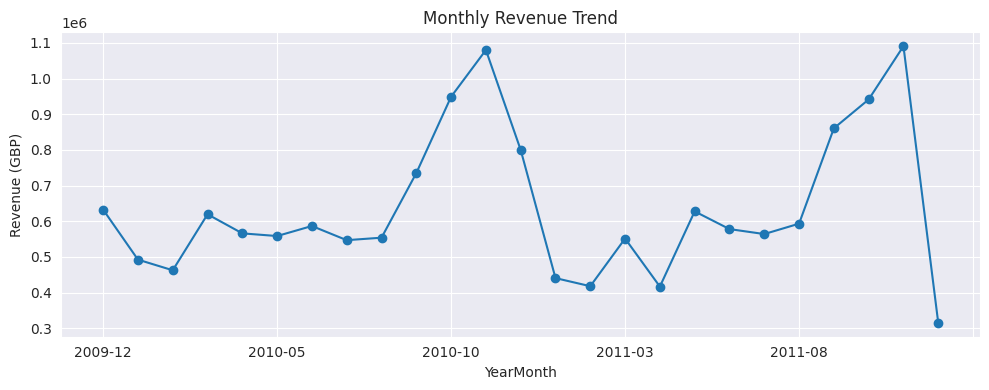

In [5]:
monthly = featured_df.groupby("YearMonth")["TotalPrice"].sum()
fig, ax = plt.subplots(figsize=(10, 4))
monthly.plot(ax=ax, marker="o")
ax.set_title("Monthly Revenue Trend")
ax.set_ylabel("Revenue (GBP)")
plt.tight_layout()
plt.show()

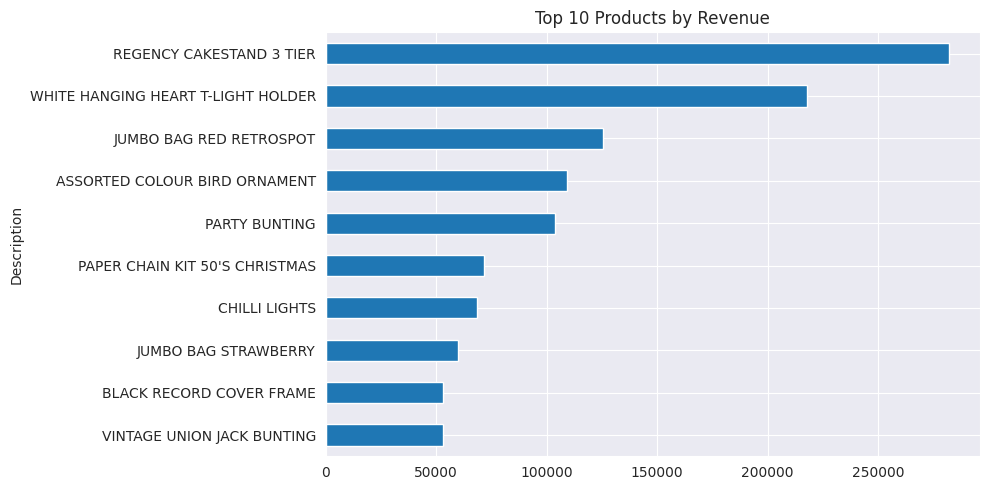

In [6]:
top_products = featured_df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_products.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 10 Products by Revenue")
plt.tight_layout()
plt.show()

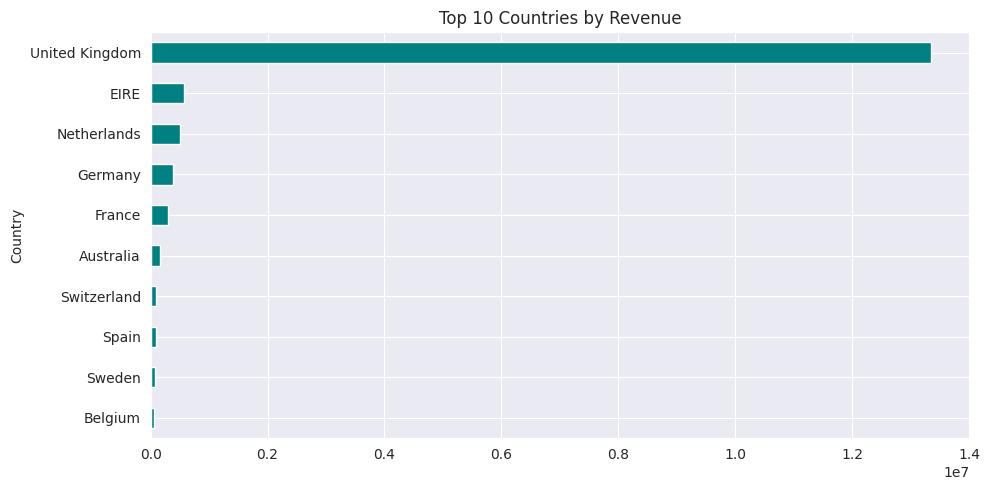

In [7]:
by_country = featured_df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 5))
by_country.sort_values().plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 10 Countries by Revenue")
plt.tight_layout()
plt.show()

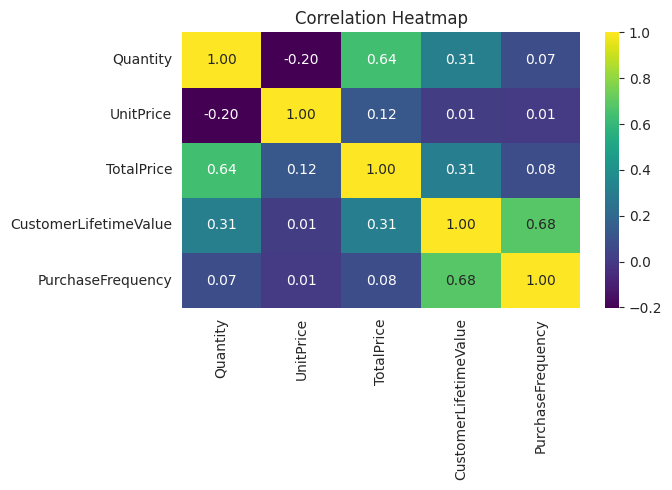

In [8]:
numeric_cols = ["Quantity", "UnitPrice", "TotalPrice", "CustomerLifetimeValue", "PurchaseFrequency"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(featured_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="viridis", ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5. Customer segmentation (RFM + KMeans)

In [9]:
rfm, silhouette = segment_customers(featured_df)
print("Silhouette score:", round(silhouette, 3))
save_parquet(rfm, cfg.RFM_SEGMENTS_PATH)
segment_summary(rfm)

2026-07-19 19:15:44 | INFO     | src.segmentation | Segmentation complete: 5862 customers, 4 clusters, silhouette=0.362


Silhouette score: 0.362


,Segment,Customers,AvgRecencyDays,AvgFrequency,AvgMonetary,TotalMonetary,PctOfCustomers,PctOfRevenue
0,Champions,975,41.765128,21.903590,11516.524533,11228611.42,16.632549,70.247997
1,Potential Loyalists,1868,98.395075,5.399358,1800.438667,3363219.43,31.866257,21.040841
2,At Risk,1635,493.285627,1.725382,504.915933,825537.55,27.891505,5.164696
3,Lost,1384,106.322977,1.713873,409.592370,566875.84,23.609690,3.546466


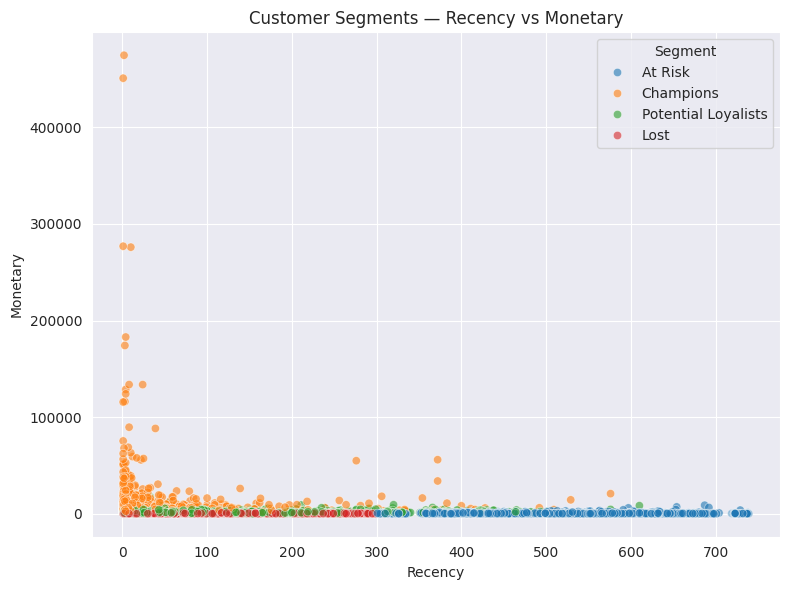

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Segment", alpha=0.6, ax=ax)
ax.set_title("Customer Segments — Recency vs Monetary")
plt.tight_layout()
plt.show()

## 6. Demand forecasting

In [11]:
forecast, engine = forecast_demand(featured_df)
print("Engine used:", engine)
save_parquet(forecast, cfg.FORECAST_PATH)
forecast_summary(forecast)

19:15:45 - cmdstanpy - INFO - Chain [1] start processing


19:15:45 - cmdstanpy - INFO - Chain [1] done processing


Engine used: Prophet


{'forecast_total': 465467.20860818576,
 'trailing_avg_daily': 41317.848,
 'forecast_avg_daily': 15515.573620272859,
 'pct_change_vs_trailing': -0.6244825330623981}

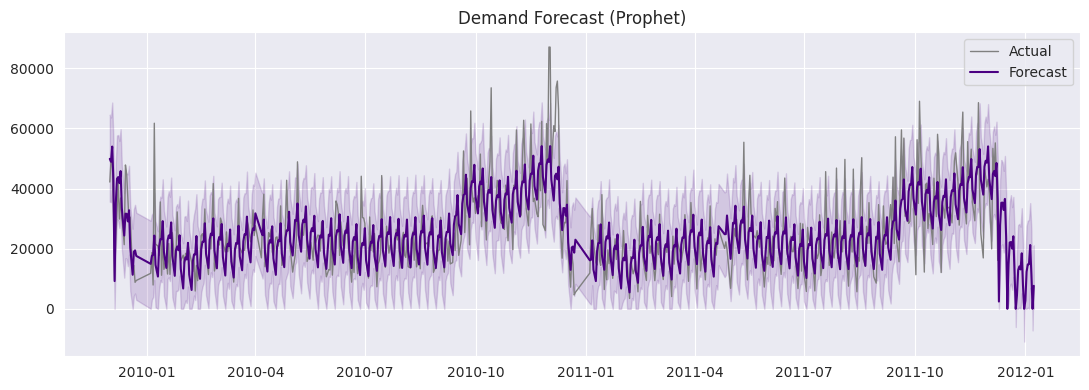

In [12]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(forecast["ds"], forecast["y"], label="Actual", color="gray", linewidth=1)
ax.plot(forecast["ds"], forecast["yhat"], label="Forecast", color="indigo", linewidth=1.5)
ax.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], color="indigo", alpha=0.15)
ax.legend()
ax.set_title(f"Demand Forecast ({engine})")
plt.tight_layout()
plt.show()

## 7. Churn analysis

In [13]:
churn_df, churn_metrics = analyze_churn(featured_df)
save_parquet(churn_df, cfg.CHURN_PATH)
print(churn_metrics)
churn_df["ChurnRiskLabel"].value_counts()

2026-07-19 19:15:47 | INFO     | src.churn | Churn model trained: {'accuracy': 0.7365223993925588, 'precision': 0.7577720207253886, 'recall': 0.785234899328859, 'f1_score': 0.7712590639419907, 'roc_auc': 0.8068029286150092, 'confusion_matrix': [[385, 187], [160, 585]], 'n_train': 3949, 'n_test': 1317, 'feature_importance': {'Recency': 0.3654, 'Frequency': 0.1792, 'Monetary': 0.2391, 'AvgOrderValue': 0.104, 'TenureDays': 0.1123}}


{'accuracy': 0.7365223993925588, 'precision': 0.7577720207253886, 'recall': 0.785234899328859, 'f1_score': 0.7712590639419907, 'roc_auc': 0.8068029286150092, 'confusion_matrix': [[385, 187], [160, 585]], 'n_train': 3949, 'n_test': 1317, 'feature_importance': {'Recency': 0.3654, 'Frequency': 0.1792, 'Monetary': 0.2391, 'AvgOrderValue': 0.104, 'TenureDays': 0.1123}}


ChurnRiskLabel
Churned    2977
Active     2262
At Risk     623
Name: count, dtype: int64

## 8. Inventory optimization

In [14]:
inv_df = optimize_inventory(featured_df)
save_parquet(inv_df, cfg.INVENTORY_PATH)
print(inventory_summary(inv_df))
inv_df.head(10)

2026-07-19 19:15:48 | INFO     | src.inventory | Inventory recommendations generated for 50 SKUs


{'increase_count': 32, 'maintain_count': 8, 'reduce_count': 10, 'total_reorder_units': 32090}


,StockCode,Description,RecentAvgDailyQty,PriorAvgDailyQty,PctChange,RecommendedAction,Confidence,SuggestedReorderQty,TotalHistoricalQty
0,85099B,JUMBO BAG RED RETROSPOT,118.27,138.03,-0.1432,Reduce Stock,0.61,1424,86603
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,119.80,79.70,0.5031,Increase Stock,0.75,1272,80781
2,21212,PACK OF 72 RETROSPOT CAKE CASES,51.53,75.43,-0.3168,Reduce Stock,0.68,640,76931
3,84879,ASSORTED COLOUR BIRD ORNAMENT,140.17,107.67,0.3019,Increase Stock,0.67,1492,67789
4,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,139.03,121.77,0.1418,Increase Stock,0.61,1434,64553
5,22197,SMALL POPCORN HOLDER,249.43,145.23,0.7175,Increase Stock,0.84,2479,51469
6,84991,60 TEATIME FAIRY CAKE CASES,41.03,46.17,-0.1112,Reduce Stock,0.59,600,46996
7,21977,PACK OF 60 PINK PAISLEY CAKE CASES,48.30,21.87,1.2088,Increase Stock,0.95,543,43377
8,20725,LUNCH BAG RED RETROSPOT,48.43,50.80,-0.0466,Maintain Stock,0.57,542,38078
9,22386,JUMBO BAG PINK POLKADOT,41.83,61.67,-0.3216,Reduce Stock,0.68,656,35624


## 9. Automated business insights

In [15]:
insights = generate_insights(featured_df, rfm, inv_df)
for ins in insights:
    print(f"[{ins['category']}] {ins['title']}: {ins['detail']}")

[Revenue] Highest Revenue Month: 2011-11 generated £1.09M in revenue, the strongest month in the dataset.
[Revenue] Lowest Revenue Month: 2011-12 was the weakest month, with only £315.2K in revenue.
[Geography] Top Market: United Kingdom is the top market, contributing £13.35M (83.5% of total revenue).
[Product] Top Revenue Product: 'REGENCY CAKESTAND 3 TIER' is the highest-grossing product at £282.0K in total sales.
[Product] Best-Selling Product by Volume: 'WHITE HANGING HEART T-LIGHT HOLDER' is the top seller by units, with 80.7K units sold.
[Trend] Fastest Growing Product: 'PIG KEYRING WITH LIGHT & SOUND' grew 1825% in the most recent 30-day period versus the prior 30 days.
[Trend] Declining Demand: 'PAINTED METAL STAR WITH HOLLY BELLS' demand fell 100% over the same comparison window and may need markdown or review.
[Customers] Most Valuable Customer Segment: 'Champions' customers drive 70.2% of total customer revenue despite being 16.6% of the customer base.
[Inventory] Stock Act